In [ ]:
import opensmile
import audiofile
import numpy as np
import pandas as pd
from pathlib import Path

video_FPS = 29.97
annotation_path = r"C:\Users\robotics\proj\Research\processed_annotation_data\ID30_annotation_processed.csv"
wav_path = r"D:\Douga_Niho\voice_data\ID30_audio.wav"

#音声ファイルの読み込み
try:
    signal, sampling_rate = audiofile.read(wav_path)
except FileExistsError:
    print(f"ファイルが見つかりません。")
    exit()
if signal.ndim == 2: #1次元に
    signal = signal[0, :]

#音声区間の抽出
df = pd.read_csv(annotation_path, header=None)

answer_df = df[df[5].astype(str).str.startswith('answer')]
#print(answer_df)

#answerの番号でsort
answer_df['sort_key'] = answer_df[5].str.extract(r'(\d+)').astype(int)
sort_df = answer_df.sort_values(by='sort_key')
sort_df = sort_df.drop(columns=['sort_key'])
#print(sort_df)

print(f"音声ファイル'{wav_path}'の分析")

all_result = []
for index, row_df in sort_df.iterrows():
    #label, frameの抽出
    label = row_df[5]
    start_frame = row_df[6]
    end_frame = start_frame + 30
    
    #frame → second → sample
    start_sec = start_frame / video_FPS
    end_sec = end_frame / video_FPS
    start_sample = int(start_sec * sampling_rate)
    end_sample = int(end_sec * sampling_rate)
    signal_slice = signal[start_sample:end_sample] #使用する音声区間

    print(signal_slice)

    if signal_slice.size > 0:
        smile = opensmile.Smile(
            feature_set= r'C:\Users\robotics\proj\delirium\Lib\site-packages\opensmile\core\config\egemaps\v02_niho\eGeMAPSv02.conf',
            feature_level=opensmile.FeatureLevel.LowLevelDescriptors,
        )

        result_df = smile.process_signal(signal_slice, sampling_rate)

        #時間情報とlabel情報を追加
        start_timedelta = pd.to_timedelta(start_sec, unit='s')
        result_df['original_start'] = result_df.index.get_level_values('start') + start_timedelta
        result_df['original_end'] = result_df.index.get_level_values('end') + start_timedelta
        result_df.insert(0, 'label', label)

        #結果を追加
        all_result.append(result_df)

    else:
        print("この区間はスキップ")

if all_result:
    print("\n結果を統合")
    final_df = pd.concat(all_result)

    #結果をCSVファイルとしてフォルダに保存
    output_folder = Path('./voice_csv_v2')
    file_path = output_folder / 'ID30_20ms.csv'
    final_df.to_csv(file_path, index=False)

    print(f"ファイルは {file_path} に保存されました。")

else:
    print("\n分析できる区間がない")

print("\nすべての処理が完了しました")    


C:\Users\robotics\AppData\Local\Temp\ipykernel_20440\2252180062.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  answer_df['sort_key'] = answer_df[5].str.extract(r'(\d+)').astype(int)


音声ファイル'D:\Douga_Niho\voice_data\ID30_audio.wav'の分析
[-0.0093689  -0.00942993 -0.00933838 ... -0.01074219 -0.01028442
 -0.01055908]
[-0.00860596 -0.0090332  -0.00946045 ... -0.00735474 -0.00753784
 -0.00784302]
[-0.00057983  0.0010376   0.00186157 ... -0.00241089 -0.00033569
  0.00067139]
[ 0.00723267  0.00765991  0.00793457 ... -0.01199341 -0.01159668
 -0.01104736]
[-0.0112915  -0.01330566 -0.01419067 ... -0.00769043 -0.00750732
 -0.0078125 ]
[ 0.00402832  0.00408936  0.00161743 ... -0.0072937  -0.00735474
 -0.00814819]
[-0.01269531 -0.01351929 -0.01513672 ... -0.01831055 -0.02087402
 -0.01989746]
[-0.00906372 -0.00872803 -0.00827026 ... -0.00946045 -0.00942993
 -0.00939941]
[-0.01092529 -0.01098633 -0.01107788 ... -0.01663208 -0.01599121
 -0.01541138]
[-0.00894165 -0.00918579 -0.01037598 ... -0.00921631 -0.0098877
 -0.01080322]

結果を統合
ファイルは voice_csv_v2\ID30_20ms.csv に保存されました。

すべての処理が完了しました


#opensmileでの抽出フェーズ

In [3]:
import opensmile
import audiofile
import numpy as np
import pandas as pd
import os
import glob

#フォルダ設定
AUDIO_INPUT_FOLDER = r"D:\Douga_Niho\voice_data"  #音声ファイルフォルダ
ANNOTATION_INPUT_FOLDER = r"C:\Users\robotics\proj\Research\processed_annotation_data"  #annotationファイルフォルダ
OUTPUT_FOLDER = "./voice_csv_200ms"  #保存フォルダ

video_FPS = 29.97

#opensmileでの処理関数
def opensmile_process(wav_path, annotation_path, output_path):

    #annotationファイルの読み込み
    try:
        df = pd.read_csv(annotation_path, header=None)
    except FileNotFoundError:
        print(f"⚠️ エラー: 参照ファイル '{annotation_path}' が見つかりません。")
        return
    
    #answer抽出
    df[5] = df[5].astype(str).str.strip()
    answer_df = df[df[5].astype(str).str.startswith('answer')]
    #print(answer_df)
    if answer_df.empty:
        print(f"⚠️ '{os.path.basename(annotation_path)}' 内に 'answer' で始まる行が見つかりません。")
        return

    #answerの番号でsort
    answer_df['sort_key'] = answer_df[5].str.extract(r'(\d+)').astype(int)
    sort_df = answer_df.sort_values(by='sort_key')
    sort_df = sort_df.drop(columns=['sort_key'])

    #音声ファイルの読み込み
    try:
        signal, sampling_rate = audiofile.read(wav_path)
    except FileExistsError:
        print(f"ファイルが見つかりません。")
        exit()
    if signal.ndim == 2: #1次元に
        signal = signal[0, :]

    print(f"音声ファイル'{wav_path}'の分析")

    all_result = []
    for index, row_df in sort_df.iterrows():
        #label, frameの抽出
        label = row_df[5]
        #start_frame = row_df[6]
        #end_frame = row_df[7]
        start = row_df[2]
        end = row_df[3]
        h_start, m_start, s_start, f_start = map(int, start.split(':'))
        start_sec = h_start * 3600 + m_start * 60 + s_start + f_start/video_FPS

        h_end, m_end, s_end, f_end = map(int, end.split(':'))
        end_sec = h_end * 3600 + m_end * 60 + s_end + f_end/video_FPS


        if end_sec > start_sec+1:
            end_sec = start_sec + 1

        #print(start_sec, end_sec)

        

        #frame → second → sample
        #start_sec = start_frame / video_FPS
        #end_sec = end_frame / video_FPS
        start_sample = int(start_sec * sampling_rate)
        end_sample = int(end_sec * sampling_rate)
        signal_slice = signal[start_sample:end_sample] #使用する音声区間をスライスで表現

        #print(signal_slice)

        if signal_slice.size > 0:
            smile = opensmile.Smile(
                feature_set= r'C:\Users\robotics\proj\delirium\Lib\site-packages\opensmile\core\config\egemaps\v02_niho\eGeMAPSv02.conf',
                feature_level=opensmile.FeatureLevel.LowLevelDescriptors,
            )

            result_df = smile.process_signal(signal_slice, sampling_rate)

            #時間情報とlabel情報を追加
            start_timedelta = pd.to_timedelta(start_sec, unit='s')
            result_df['original_start'] = result_df.index.get_level_values('start') + start_timedelta
            result_df['original_end'] = result_df.index.get_level_values('end') + start_timedelta
            result_df.insert(0, 'label', label)

            #結果を追加
            all_result.append(result_df)

        else:
            print("この区間はスキップ")

    if all_result:
        print("\n結果を統合")
        final_df = pd.concat(all_result)
        final_df.to_csv(output_path)

        print(f"ファイルは {output_path} に保存されました。")

    else:
        print("\n分析できる区間がない")

    
#メイン処理
if __name__ == "__main__":
    print("すべてのファイルの処理を開始")

    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    # 音声フォルダ内の全ての.wavファイルを検索
    audio_files = glob.glob(os.path.join(AUDIO_INPUT_FOLDER, '*.wav'))

    if not audio_files:
        print("音声ファイルがありません。")
    else:
        for audio_path in audio_files:
            base_name = os.path.basename(audio_path)

            try:
                file_id = base_name.split('_')[0]
            except IndexError:
                print("ファイル名が作成できません。")
                continue

            print(f"\nID : {file_id}の処理を開始")

            annotation_path = os.path.join(ANNOTATION_INPUT_FOLDER, f"{file_id}_annotation_processed.csv")
            output_path = os.path.join(OUTPUT_FOLDER, f"{file_id}_200ms.csv")

            if os.path.exists(annotation_path):
                opensmile_process(audio_path, annotation_path, output_path)
            else:
                print("annotationファイルが見つかりませんでした。")
                    
    print("\n--- 全ての処理が完了しました ---")


すべてのファイルの処理を開始

ID : ID57の処理を開始
音声ファイル'D:\Douga_Niho\voice_data\ID57_audio.wav'の分析


C:\Users\robotics\AppData\Local\Temp\ipykernel_4352\2326388314.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  answer_df['sort_key'] = answer_df[5].str.extract(r'(\d+)').astype(int)



結果を統合
ファイルは ./voice_csv_200ms\ID57_200ms.csv に保存されました。

ID : ID58の処理を開始
音声ファイル'D:\Douga_Niho\voice_data\ID58_audio.wav'の分析


C:\Users\robotics\AppData\Local\Temp\ipykernel_4352\2326388314.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  answer_df['sort_key'] = answer_df[5].str.extract(r'(\d+)').astype(int)



結果を統合
ファイルは ./voice_csv_200ms\ID58_200ms.csv に保存されました。

ID : ID59の処理を開始
音声ファイル'D:\Douga_Niho\voice_data\ID59_audio.wav'の分析


...


結果を統合
ファイルは ./voice_csv_200ms\ID55_200ms.csv に保存されました。

ID : ID56の処理を開始
音声ファイル'D:\Douga_Niho\voice_data\ID56_audio.wav'の分析


C:\Users\robotics\AppData\Local\Temp\ipykernel_4352\2326388314.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  answer_df['sort_key'] = answer_df[5].str.extract(r'(\d+)').astype(int)



結果を統合
ファイルは ./voice_csv_200ms\ID56_200ms.csv に保存されました。

ID : ID49の処理を開始
音声ファイル'D:\Douga_Niho\voice_data\ID49_audio.wav'の分析


C:\Users\robotics\AppData\Local\Temp\ipykernel_4352\2326388314.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  answer_df['sort_key'] = answer_df[5].str.extract(r'(\d+)').astype(int)



結果を統合
ファイルは ./voice_csv_200ms\ID49_200ms.csv に保存されました。

--- 全ての処理が完了しました ---


#学習フェーズ（層化5分割交差検証）

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
#from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_v2')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})

files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['ID', 'Sex'], inplace=True)
#print(file_with_labels_df)
#print(file_with_labels_df.columns)


#層化5分割交差検証
model = RandomForestClassifier(random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

X_files = file_with_labels_df
#print(X_files)
y_labels = file_with_labels_df['Delirium']

for fold, (train_indices, test_indices) in enumerate(skf.split(X_files, y_labels)):

    train_files = X_files.iloc[train_indices]
    test_files = X_files.iloc[test_indices]


    #print(train_files)

    print(f"--- Fold {fold+1} ---")
    print(f"訓練ファイル数: {len(train_files)}, テストファイル数: {len(test_files)}")

    train_files_path = [folder_path / fname for fname in train_files['filename']]
    test_files_path = [folder_path / fname for fname in test_files['filename']]
    #print(train_files_path)

    train_df = pd.concat([pd.read_csv(f) for f in train_files_path], ignore_index=True)
    test_df = pd.concat([pd.read_csv(f) for f in test_files_path], ignore_index=True)
    #print(train_df)
    #print(test_df)

    #print(f"元の訓練データ行数: {len(train_df)}")
    train_df = train_df.iloc[::2]
    train_df = train_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(train_df)}")

    #print(f"元の訓練データ行数: {len(test_df)}")
    test_df = test_df.iloc[::2]
    test_df = test_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(test_df)}")


    columns_drop = ['start', 'end', 'label', 'alphaRatio_sma3', 'hammarbergIndex_sma3', 'slope0-500_sma3', 'slope500-1500_sma3', 'mfcc1_sma3', 'mfcc2_sma3', 'mfcc3_sma3', 'mfcc4_sma3', 'logRelF0-H1-H2_sma3nz', 'logRelF0-H1-A3_sma3nz', 'original_start', 'original_end']

    y_train = y_labels.iloc[train_indices].repeat([len(pd.read_csv(f)) for f in train_files_path])
    y_test = y_labels.iloc[test_indices].repeat([len(pd.read_csv(f)) for f in test_files_path])

    #print(f"元の訓練データ行数: {len(y_train)}")
    y_train = y_train.iloc[::2]
    y_train = y_train.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_train)}")

    #print(f"元の訓練データ行数: {len(y_test)}")
    y_test = y_test.iloc[::2]
    y_test = y_test.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_test)}")


    X_train = train_df.drop(columns=columns_drop, errors='ignore')
    X_test = test_df.drop(columns=columns_drop, errors='ignore')

    print(X_train)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    scores.append(accuracy)
    print(f"このFoldの正解率: {accuracy:.4f}\n")

print("--- 最終結果 ---")
print(f"平均正解率: {np.mean(scores):.4f}")
print(f"正解率の標準偏差: {np.std(scores):.4f}")



--- Fold 1 ---
訓練ファイル数: 52, テストファイル数: 13
       Loudness_sma3  spectralFlux_sma3  F0semitoneFrom27.5Hz_sma3nz  \
0           0.144024           0.005333                     0.000000   
1           0.144741           0.016569                     0.000000   
2           0.141315           0.016856                     0.000000   
3           0.136340           0.021465                     0.000000   
4           0.152333           0.023011                     0.000000   
...              ...                ...                          ...   
23947       0.315137           0.216782                    23.152008   
23948       0.653328           0.870646                    43.287518   
23949       1.095913           1.210105                    44.375550   
23950       1.293434           0.953099                    45.535680   
23951       1.210705           1.128397                    46.913876   

       jitterLocal_sma3nz  shimmerLocaldB_sma3nz  HNRdBACF_sma3nz  \
0                0.000000

#クロスバリデーション（MFCC無）

In [26]:
from pathlib import Path
import numpy as np
import pandas as pd
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

#pd.set_option('display.max_rows', None)

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_20ms')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})

files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].astype(str).str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['ID', 'Sex'], inplace=True)
#print(file_with_labels_df)
#print(file_with_labels_df.columns)

#KFold Cross Validation
model = RandomForestClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

X_files = file_with_labels_df
#print(X_files)
y_labels = file_with_labels_df['Delirium']
#print(y_labels)

for fold, (train_indices, test_indices) in enumerate(kf.split(X_files)):

    train_files = X_files.iloc[train_indices]
    test_files = X_files.iloc[test_indices]

    print(f"--- Fold {fold+1} ---")
    print(f"訓練ファイル数: {len(train_files)}, テストファイル数: {len(test_files)}")

    #print(test_files)

    train_files_path = [folder_path / fname for fname in train_files['filename']]
    test_files_path = [folder_path / fname for fname in test_files['filename']]
    #print(train_files_path)
    
    #学習データ
    train_df = pd.concat([pd.read_csv(f).merge(X_files, left_on=pd.Series([os.path.basename(f)]*len(pd.read_csv(f)), name='filename'), right_on='filename', how='left').groupby('label').apply(lambda x: x.iloc[::2], include_groups=False) for f in train_files_path], ignore_index=True)
    #テストデータ
    test_file_lengths = []
    test_processed_df = []
    for f in test_files_path:
        filename = os.path.basename(f)
        processed_df = (pd.read_csv(f).assign(filename=filename).merge(X_files, on='filename', how='left').groupby('label').apply(lambda x: x.iloc[::2], include_groups=False))
        test_file_lengths.append(len(processed_df))
        test_processed_df.append(processed_df)
    
    test_df = pd.concat(test_processed_df, ignore_index=True)

    #train_df = pd.concat([pd.read_csv(f).iloc[::2] for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f).iloc[::2] for f in test_files_path], ignore_index=True)

    #train_df = pd.concat([pd.read_csv(f) for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f) for f in test_files_path], ignore_index=True)
    #print(train_df)
    #print(test_df)

    #print(f"元の訓練データ行数: {len(train_df)}")
    #train_df = train_df.iloc[::2]
    #train_df = train_df.reset_index(drop=True)
    print(f"間引き後の訓練データ行数: {len(train_df)}")

    #print(f"元の訓練データ行数: {len(test_df)}")
    #test_df = test_df.iloc[::2]
    #test_df = test_df.reset_index(drop=True)
    print(f"間引き後の訓練データ行数: {len(test_df)}")


    columns_drop = ['start', 'end', 'label', 'Loudness_sma3', 'alphaRatio_sma3', 'hammarbergIndex_sma3', 'slope0-500_sma3', 'slope500-1500_sma3', 'mfcc1_sma3', 'mfcc2_sma3', 'mfcc3_sma3', 'mfcc4_sma3', 'logRelF0-H1-H2_sma3nz', 'logRelF0-H1-A3_sma3nz', 'original_start', 'original_end','filepath', 'filename', 'Delirium']

    y_train = train_df['Delirium']
    y_test = test_df['Delirium']
    #print(y_train)
    #print(y_test)

    #y_train = y_labels.iloc[train_indices].repeat([len(pd.read_csv(f)) for f in train_files_path])
    #y_test = y_labels.iloc[test_indices].repeat([len(pd.read_csv(f)) for f in test_files_path])

    #print(f"元の訓練データ行数: {len(y_train)}")
    #y_train = y_train.iloc[::2]
    #y_train = y_train.reset_index(drop=True)
    print(f"間引き後の訓練データ行数: {len(y_train)}")

    #print(f"元の訓練データ行数: {len(y_test)}")
    #y_test = y_test.iloc[::2]
    #y_test = y_test.reset_index(drop=True)
    print(f"間引き後の訓練データ行数: {len(y_test)}")


    X_train = train_df.drop(columns=columns_drop, errors='ignore')
    X_test = test_df.drop(columns=columns_drop, errors='ignore')

    #print(X_train)
    #print(X_test)
    #print(y_train)
    #print(y_test)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    #print(y_pred)

    file_predictions = []

    # 各テストファイルの行数を事前に計算しておく
    #test_file_lengths = [len(pd.read_csv(f)) for f in test_files_path]
    #print(test_file_lengths)

    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        #print(start_idx, end_idx)
        predictions_for_this_file = y_pred[start_idx:end_idx]
        #print(predictions_for_this_file.shape)
        majority_vote = mode(predictions_for_this_file)[0]
        #print(majority_vote)
        file_predictions.append(majority_vote)
        start_idx = end_idx

    y_test_files = test_files['Delirium'].values

    test_files_copy = test_files
    #test_files_copy['Predict'] = file_predictions
    test_files_copy = test_files_copy.assign(Prediction=file_predictions)

    print(test_files_copy)

    correct_files = np.sum(np.array(file_predictions) == y_test_files)
    total_files = len(test_files)
    accuracy = correct_files/ total_files

    scores.append(accuracy)
    print("\n")
    print(f"このFoldの正解率 (ファイル単位): {accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")

    # 4-2. 混同行列の計算
    # y_test_files (正解ラベル) と file_predictions (予測ラベル) を渡す
    cm = confusion_matrix(y_test_files, file_predictions)

    # 4-3. 見やすいようにDataFrameに変換して表示
    # ラベルが0と1の場合
    cm_df = pd.DataFrame(cm, 
                     index=['正解: 0', '正解: 1'], 
                     columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train.columns.tolist()
    
    importances = model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)

    #特徴量ごとの散布図を比較
    #feature_name = 'Loudness_sma3'

    #fig, (sp1, sp2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    #fig.suptitle(f'{feature_name}', fontsize=16)

    #sp1.scatter(range(len(X_train)), X_train[feature_name], alpha=0.6)
    #sp1.set_title('train data')
    #sp1.set_xlabel('index')
    #sp1.set_ylabel(feature_name)
    #sp1.grid(True)

    #sp2.scatter(range(len(X_test)), X_test[feature_name], alpha=0.6)
    #sp2.set_title('test data')
    #sp2.set_xlabel('index')
    #sp2.set_ylabel(feature_name)
    #sp2.grid(True)

    #グラフを表示
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.show()

    

total_accuracy = sum(scores) / len(scores)
print(f"5つのFoldのファイル単位での平均正解率：{total_accuracy:.4f}\n")
print(f"5つのFoldのファイル単位での性能のばらつき(標準偏差)：{np.std(scores):.4f}")

--- Fold 1 ---
訓練ファイル数: 52, テストファイル数: 13
間引き後の訓練データ行数: 22391
間引き後の訓練データ行数: 5838
間引き後の訓練データ行数: 22391
間引き後の訓練データ行数: 5838
                        filepath       filename  Delirium  Prediction
0   voice_csv_20ms\ID30_20ms.csv  ID30_20ms.csv         0           1
5   voice_csv_20ms\ID35_20ms.csv  ID35_20ms.csv         0           1
9   voice_csv_20ms\ID39_20ms.csv  ID39_20ms.csv         0           0
12  voice_csv_20ms\ID42_20ms.csv  ID42_20ms.csv         0           0
16  voice_csv_20ms\ID46_20ms.csv  ID46_20ms.csv         1           0
30  voice_csv_20ms\ID60_20ms.csv  ID60_20ms.csv         0           0
33  voice_csv_20ms\ID63_20ms.csv  ID63_20ms.csv         1           0
41  voice_csv_20ms\ID71_20ms.csv  ID71_20ms.csv         1           0
45  voice_csv_20ms\ID75_20ms.csv  ID75_20ms.csv         1           0
53  voice_csv_20ms\ID83_20ms.csv  ID83_20ms.csv         1           0
60  voice_csv_20ms\ID90_20ms.csv  ID90_20ms.csv         1           0
61  voice_csv_20ms\ID91_20ms.csv  ID91_20

#クロスバリデーション（MFCC有）

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_20ms')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})

files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['ID', 'Sex'], inplace=True)
#print(file_with_labels_df)
#print(file_with_labels_df.columns)

#KFold Cross Validation
model = RandomForestClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

X_files = file_with_labels_df
#print(X_files)
y_labels = file_with_labels_df['Delirium']

for fold, (train_indices, test_indices) in enumerate(kf.split(X_files)):

    train_files = X_files.iloc[train_indices]
    test_files = X_files.iloc[test_indices]

    print(f"--- Fold {fold+1} ---")
    print(f"訓練ファイル数: {len(train_files)}, テストファイル数: {len(test_files)}")

    #print(test_files)

    train_files_path = [folder_path / fname for fname in train_files['filename']]
    test_files_path = [folder_path / fname for fname in test_files['filename']]
    #print(train_files_path)

    train_df = pd.concat([pd.read_csv(f).iloc[::2] for f in train_files_path], ignore_index=True)
    test_df = pd.concat([pd.read_csv(f).iloc[::2] for f in test_files_path], ignore_index=True)

    #train_df = pd.concat([pd.read_csv(f) for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f) for f in test_files_path], ignore_index=True)
    #print(train_df)
    #print(test_df)

    #print(f"元の訓練データ行数: {len(train_df)}")
    #train_df = train_df.iloc[::2]
    #train_df = train_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(train_df)}")

    #print(f"元の訓練データ行数: {len(test_df)}")
    #test_df = test_df.iloc[::2]
    #test_df = test_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(test_df)}")


    columns_drop = ['start', 'end', 'label', 'alphaRatio_sma3', 'hammarbergIndex_sma3', 'slope0-500_sma3', 'slope500-1500_sma3', 'logRelF0-H1-H2_sma3nz', 'logRelF0-H1-A3_sma3nz', 'original_start', 'original_end']

    y_train = y_labels.iloc[train_indices].repeat([len(pd.read_csv(f)) for f in train_files_path])
    y_test = y_labels.iloc[test_indices].repeat([len(pd.read_csv(f)) for f in test_files_path])

    #print(f"元の訓練データ行数: {len(y_train)}")
    y_train = y_train.iloc[::2]
    y_train = y_train.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_train)}")

    #print(f"元の訓練データ行数: {len(y_test)}")
    y_test = y_test.iloc[::2]
    y_test = y_test.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_test)}")


    X_train = train_df.drop(columns=columns_drop, errors='ignore')
    X_test = test_df.drop(columns=columns_drop, errors='ignore')

    #print(X_train)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    #print(y_pred)

    file_predictions = []

    # 各テストファイルの行数を事前に計算しておく
    test_file_lengths = [len(pd.read_csv(f).iloc[::2]) for f in test_files_path]
    #print(test_file_lengths)

    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        #print(start_idx, end_idx)
        predictions_for_this_file = y_pred[start_idx:end_idx]
        #print(predictions_for_this_file.shape)
        majority_vote = mode(predictions_for_this_file)[0]
        #print(majority_vote)
        file_predictions.append(majority_vote)
        start_idx = end_idx

    y_test_files = test_files['Delirium'].values

    test_files_copy = test_files
    #test_files_copy['Predict'] = file_predictions
    test_files_copy = test_files_copy.assign(Prediction=file_predictions)

    print(test_files_copy)

    correct_files = np.sum(np.array(file_predictions) == y_test_files)
    total_files = len(test_files)
    accuracy = correct_files/ total_files

    scores.append(accuracy)
    print("\n")
    print(f"このFoldの正解率 (ファイル単位): {accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")

    # 4-2. 混同行列の計算
    # y_test_files (正解ラベル) と file_predictions (予測ラベル) を渡す
    cm = confusion_matrix(y_test_files, file_predictions)

    # 4-3. 見やすいようにDataFrameに変換して表示
    # ラベルが0と1の場合
    cm_df = pd.DataFrame(cm, 
                     index=['正解: 0', '正解: 1'], 
                     columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train.columns.tolist()
    
    importances = model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)

    #特徴量ごとの散布図を比較
    #feature_name = 'Loudness_sma3'

    #fig, (sp1, sp2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    #fig.suptitle(f'{feature_name}', fontsize=16)

    #sp1.scatter(range(len(X_train)), X_train[feature_name], alpha=0.6)
    #sp1.set_title('train data')
    #sp1.set_xlabel('index')
    #sp1.set_ylabel(feature_name)
    #sp1.grid(True)

    #sp2.scatter(range(len(X_test)), X_test[feature_name], alpha=0.6)
    #sp2.set_title('test data')
    #sp2.set_xlabel('index')
    #sp2.set_ylabel(feature_name)
    #sp2.grid(True)

    #グラフを表示
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.show()

    

total_accuracy = sum(scores) / len(scores)
print(f"5つのFoldのファイル単位での平均正解率：{total_accuracy:.4f}\n")
print(f"5つのFoldのファイル単位での性能のばらつき(標準偏差)：{np.std(scores):.4f}")

--- Fold 1 ---
訓練ファイル数: 52, テストファイル数: 13
                        filepath       filename  Delirium  Prediction
0   voice_csv_20ms\ID30_20ms.csv  ID30_20ms.csv         0           0
5   voice_csv_20ms\ID35_20ms.csv  ID35_20ms.csv         0           1
9   voice_csv_20ms\ID39_20ms.csv  ID39_20ms.csv         0           0
12  voice_csv_20ms\ID42_20ms.csv  ID42_20ms.csv         0           0
16  voice_csv_20ms\ID46_20ms.csv  ID46_20ms.csv         1           0
30  voice_csv_20ms\ID60_20ms.csv  ID60_20ms.csv         0           0
33  voice_csv_20ms\ID63_20ms.csv  ID63_20ms.csv         1           1
41  voice_csv_20ms\ID71_20ms.csv  ID71_20ms.csv         1           0
45  voice_csv_20ms\ID75_20ms.csv  ID75_20ms.csv         1           1
53  voice_csv_20ms\ID83_20ms.csv  ID83_20ms.csv         1           0
60  voice_csv_20ms\ID90_20ms.csv  ID90_20ms.csv         1           0
61  voice_csv_20ms\ID91_20ms.csv  ID91_20ms.csv         1           0
64  voice_csv_20ms\ID94_20ms.csv  ID94_20ms.csv  

#重要度の高い特徴量のみでクロスバリデーション

In [46]:
from pathlib import Path
import numpy as np
import pandas as pd
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_v2')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})

files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['ID', 'Sex'], inplace=True)
#print(file_with_labels_df)
#print(file_with_labels_df.columns)

#KFold Cross Validation
model = RandomForestClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

X_files = file_with_labels_df
#print(X_files)
y_labels = file_with_labels_df['Delirium']

for fold, (train_indices, test_indices) in enumerate(kf.split(X_files)):

    train_files = X_files.iloc[train_indices]
    test_files = X_files.iloc[test_indices]

    print(f"--- Fold {fold+1} ---")
    print(f"訓練ファイル数: {len(train_files)}, テストファイル数: {len(test_files)}")

    #print(test_files)

    train_files_path = [folder_path / fname for fname in train_files['filename']]
    test_files_path = [folder_path / fname for fname in test_files['filename']]
    #print(train_files_path)

    train_df = pd.concat([pd.read_csv(f).iloc[::2] for f in train_files_path], ignore_index=True)
    test_df = pd.concat([pd.read_csv(f).iloc[::2] for f in test_files_path], ignore_index=True)

    #train_df = pd.concat([pd.read_csv(f) for f in train_files_path], ignore_index=True)
    #test_df = pd.concat([pd.read_csv(f) for f in test_files_path], ignore_index=True)
    #print(train_df)
    #print(test_df)

    #print(f"元の訓練データ行数: {len(train_df)}")
    #train_df = train_df.iloc[::2]
    #train_df = train_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(train_df)}")

    #print(f"元の訓練データ行数: {len(test_df)}")
    #test_df = test_df.iloc[::2]
    #test_df = test_df.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(test_df)}")


    columns_drop = ['start',
                     'end',
                    'label', 
                    'alphaRatio_sma3', 
                    'hammarbergIndex_sma3', 
                    'slope0-500_sma3', 
                    'slope500-1500_sma3', 
                    'logRelF0-H1-H2_sma3nz', 
                    'logRelF0-H1-A3_sma3nz', 
                    'original_start', 
                    'original_end',
                    'jitterLocal_sma3nz', 
                    'HNRdBACF_sma3nz', 
                    'F2amplitudeLogRelF0_sma3nz', 
                    'F3amplitudeLogRelF0_sma3nz', 
                    'F1amplitudeLogRelF0_sma3nz', 
                    'shimmerLocaldB_sma3nz', 
                    'F2bandwidth_sma3nz', 
                    'F1bandwidth_sma3nz',
                    'F3bandwidth_sma3nz',
                    'F0semitoneFrom27.5Hz_sma3nz',
                    'F1frequency_sma3nz',
                    'F2frequency_sma3nz',
                    'F3frequency_sma3nz']

    y_train = y_labels.iloc[train_indices].repeat([len(pd.read_csv(f)) for f in train_files_path])
    y_test = y_labels.iloc[test_indices].repeat([len(pd.read_csv(f)) for f in test_files_path])

    #print(f"元の訓練データ行数: {len(y_train)}")
    y_train = y_train.iloc[::2]
    y_train = y_train.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_train)}")

    #print(f"元の訓練データ行数: {len(y_test)}")
    y_test = y_test.iloc[::2]
    y_test = y_test.reset_index(drop=True)
    #print(f"間引き後の訓練データ行数: {len(y_test)}")


    X_train = train_df.drop(columns=columns_drop, errors='ignore')
    X_test = test_df.drop(columns=columns_drop, errors='ignore')

    #print(X_train)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    #print(y_pred)

    file_predictions = []

    # 各テストファイルの行数を事前に計算しておく
    test_file_lengths = [len(pd.read_csv(f).iloc[::2]) for f in test_files_path]
    #print(test_file_lengths)

    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        #print(start_idx, end_idx)
        predictions_for_this_file = y_pred[start_idx:end_idx]
        #print(predictions_for_this_file.shape)
        majority_vote = mode(predictions_for_this_file)[0]
        #print(majority_vote)
        file_predictions.append(majority_vote)
        start_idx = end_idx

    y_test_files = test_files['Delirium'].values

    test_files_copy = test_files
    #test_files_copy['Predict'] = file_predictions
    test_files_copy = test_files_copy.assign(Prediction=file_predictions)

    print(test_files_copy)

    correct_files = np.sum(np.array(file_predictions) == y_test_files)
    total_files = len(test_files)
    accuracy = correct_files/ total_files

    scores.append(accuracy)
    print("\n")
    print(f"このFoldの正解率 (ファイル単位): {accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")

    # 4-2. 混同行列の計算
    # y_test_files (正解ラベル) と file_predictions (予測ラベル) を渡す
    cm = confusion_matrix(y_test_files, file_predictions)

    # 4-3. 見やすいようにDataFrameに変換して表示
    # ラベルが0と1の場合
    cm_df = pd.DataFrame(cm, 
                     index=['正解: 0', '正解: 1'], 
                     columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train.columns.tolist()
    
    importances = model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)

    #特徴量ごとの散布図を比較
    #feature_name = 'Loudness_sma3'

    #fig, (sp1, sp2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    #fig.suptitle(f'{feature_name}', fontsize=16)

    #sp1.scatter(range(len(X_train)), X_train[feature_name], alpha=0.6)
    #sp1.set_title('train data')
    #sp1.set_xlabel('index')
    #sp1.set_ylabel(feature_name)
    #sp1.grid(True)

    #sp2.scatter(range(len(X_test)), X_test[feature_name], alpha=0.6)
    #sp2.set_title('test data')
    #sp2.set_xlabel('index')
    #sp2.set_ylabel(feature_name)
    #sp2.grid(True)

    #グラフを表示
    #plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.show()

    

total_accuracy = sum(scores) / len(scores)
print(f"5つのFoldのファイル単位での平均正解率：{total_accuracy:.4f}\n")
print(f"5つのFoldのファイル単位での性能のばらつき(標準偏差)：{np.std(scores):.4f}")

--- Fold 1 ---
訓練ファイル数: 52, テストファイル数: 13
                      filepath       filename  Delirium  Prediction
0   voice_csv_v2\ID30_20ms.csv  ID30_20ms.csv         0           0
5   voice_csv_v2\ID35_20ms.csv  ID35_20ms.csv         0           1
9   voice_csv_v2\ID39_20ms.csv  ID39_20ms.csv         0           0
12  voice_csv_v2\ID42_20ms.csv  ID42_20ms.csv         0           0
16  voice_csv_v2\ID46_20ms.csv  ID46_20ms.csv         1           0
30  voice_csv_v2\ID60_20ms.csv  ID60_20ms.csv         0           0
33  voice_csv_v2\ID63_20ms.csv  ID63_20ms.csv         1           0
41  voice_csv_v2\ID71_20ms.csv  ID71_20ms.csv         1           0
45  voice_csv_v2\ID75_20ms.csv  ID75_20ms.csv         1           0
53  voice_csv_v2\ID83_20ms.csv  ID83_20ms.csv         1           0
60  voice_csv_v2\ID90_20ms.csv  ID90_20ms.csv         1           0
61  voice_csv_v2\ID91_20ms.csv  ID91_20ms.csv         1           0
64  voice_csv_v2\ID94_20ms.csv  ID94_20ms.csv         1           0


このFol

#せん妄の有無による特徴量ごとの分布（20ms）

C:\Users\robotics\AppData\Local\Temp\ipykernel_11168\3098607783.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


([<matplotlib.axis.YTick at 0x1dbd08de3c0>,
 [Text(0, 0, 'Delirium 0'), Text(0, 1, 'Delirium 1')])

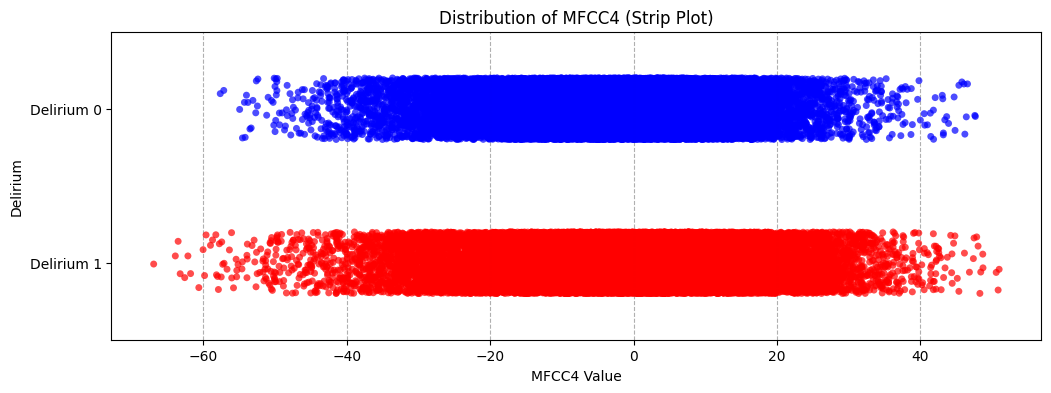

In [1]:
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_v2')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})

files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['Sex'], inplace=True)
#print(file_with_labels_df)
#print(file_with_labels_df.columns)

processed_df = {}

for index, row in file_with_labels_df.iterrows():
    filepath = row['filepath']
    delirium = row['Delirium']
    ID = row['ID']

    #print(f"{ID}, ラベル：{delirium}")

    df = pd.read_csv(filepath)

    df['Delirium'] = delirium

    processed_df[ID] = df

#print("\n--- 処理後のデータフレームの確認ID ---")
#print(processed_df[30])

dfs_with_label_0 = []
dfs_with_label_1 = []

for df in processed_df.values():
    label_value = df['Delirium'].iloc[0]
    #print(label_value)

    if label_value == 0:
        dfs_with_label_0.append(df)
    elif label_value == 1:
        dfs_with_label_1.append(df)

final_df_0 = pd.concat(dfs_with_label_0, ignore_index=True)
final_df_1 = pd.concat(dfs_with_label_1, ignore_index=True)

#print(" ラベルが 0 の結合されたデータフレーム")
#print(final_df_0)

#print("\nラベルが 1 の結合されたデータフレーム")
#print(final_df_1)

#散布図
#plt.figure(figsize=(8, 6))

#plt.scatter(final_df_0['Lundness'],)

combined_df = pd.concat([final_df_0, final_df_1])
# -----------------------------


# --- ストリッププロットの作成 ---
plt.figure(figsize=(12, 4)) # 横長のグラフにすると見やすい

# stripplot を使って描画
sns.stripplot(
    data=combined_df,
    x='mfcc4_sma3',      # x軸に分布を見たい特徴量を指定
    y='Delirium',          # y軸にカテゴリ（今回はlabel）を指定すると、自動で分けてくれる
    orient='h',         # グラフを水平方向にする
    jitter=0.2,         # ジッター（点のばらつき具合）を調整
    alpha=0.7,          # 点の透明度
    palette=['blue', 'red'] # 色を指定
)

# --- グラフの装飾 ---
plt.title('Distribution of MFCC4 (Strip Plot)')
plt.xlabel('MFCC4 Value')
plt.ylabel('Delirium')
plt.grid(axis='x', linestyle='--')
plt.yticks([0, 1], ['Delirium 0', 'Delirium 1']) # y軸のラベルを分かりやすくする


#20msと100msでの分布の違い

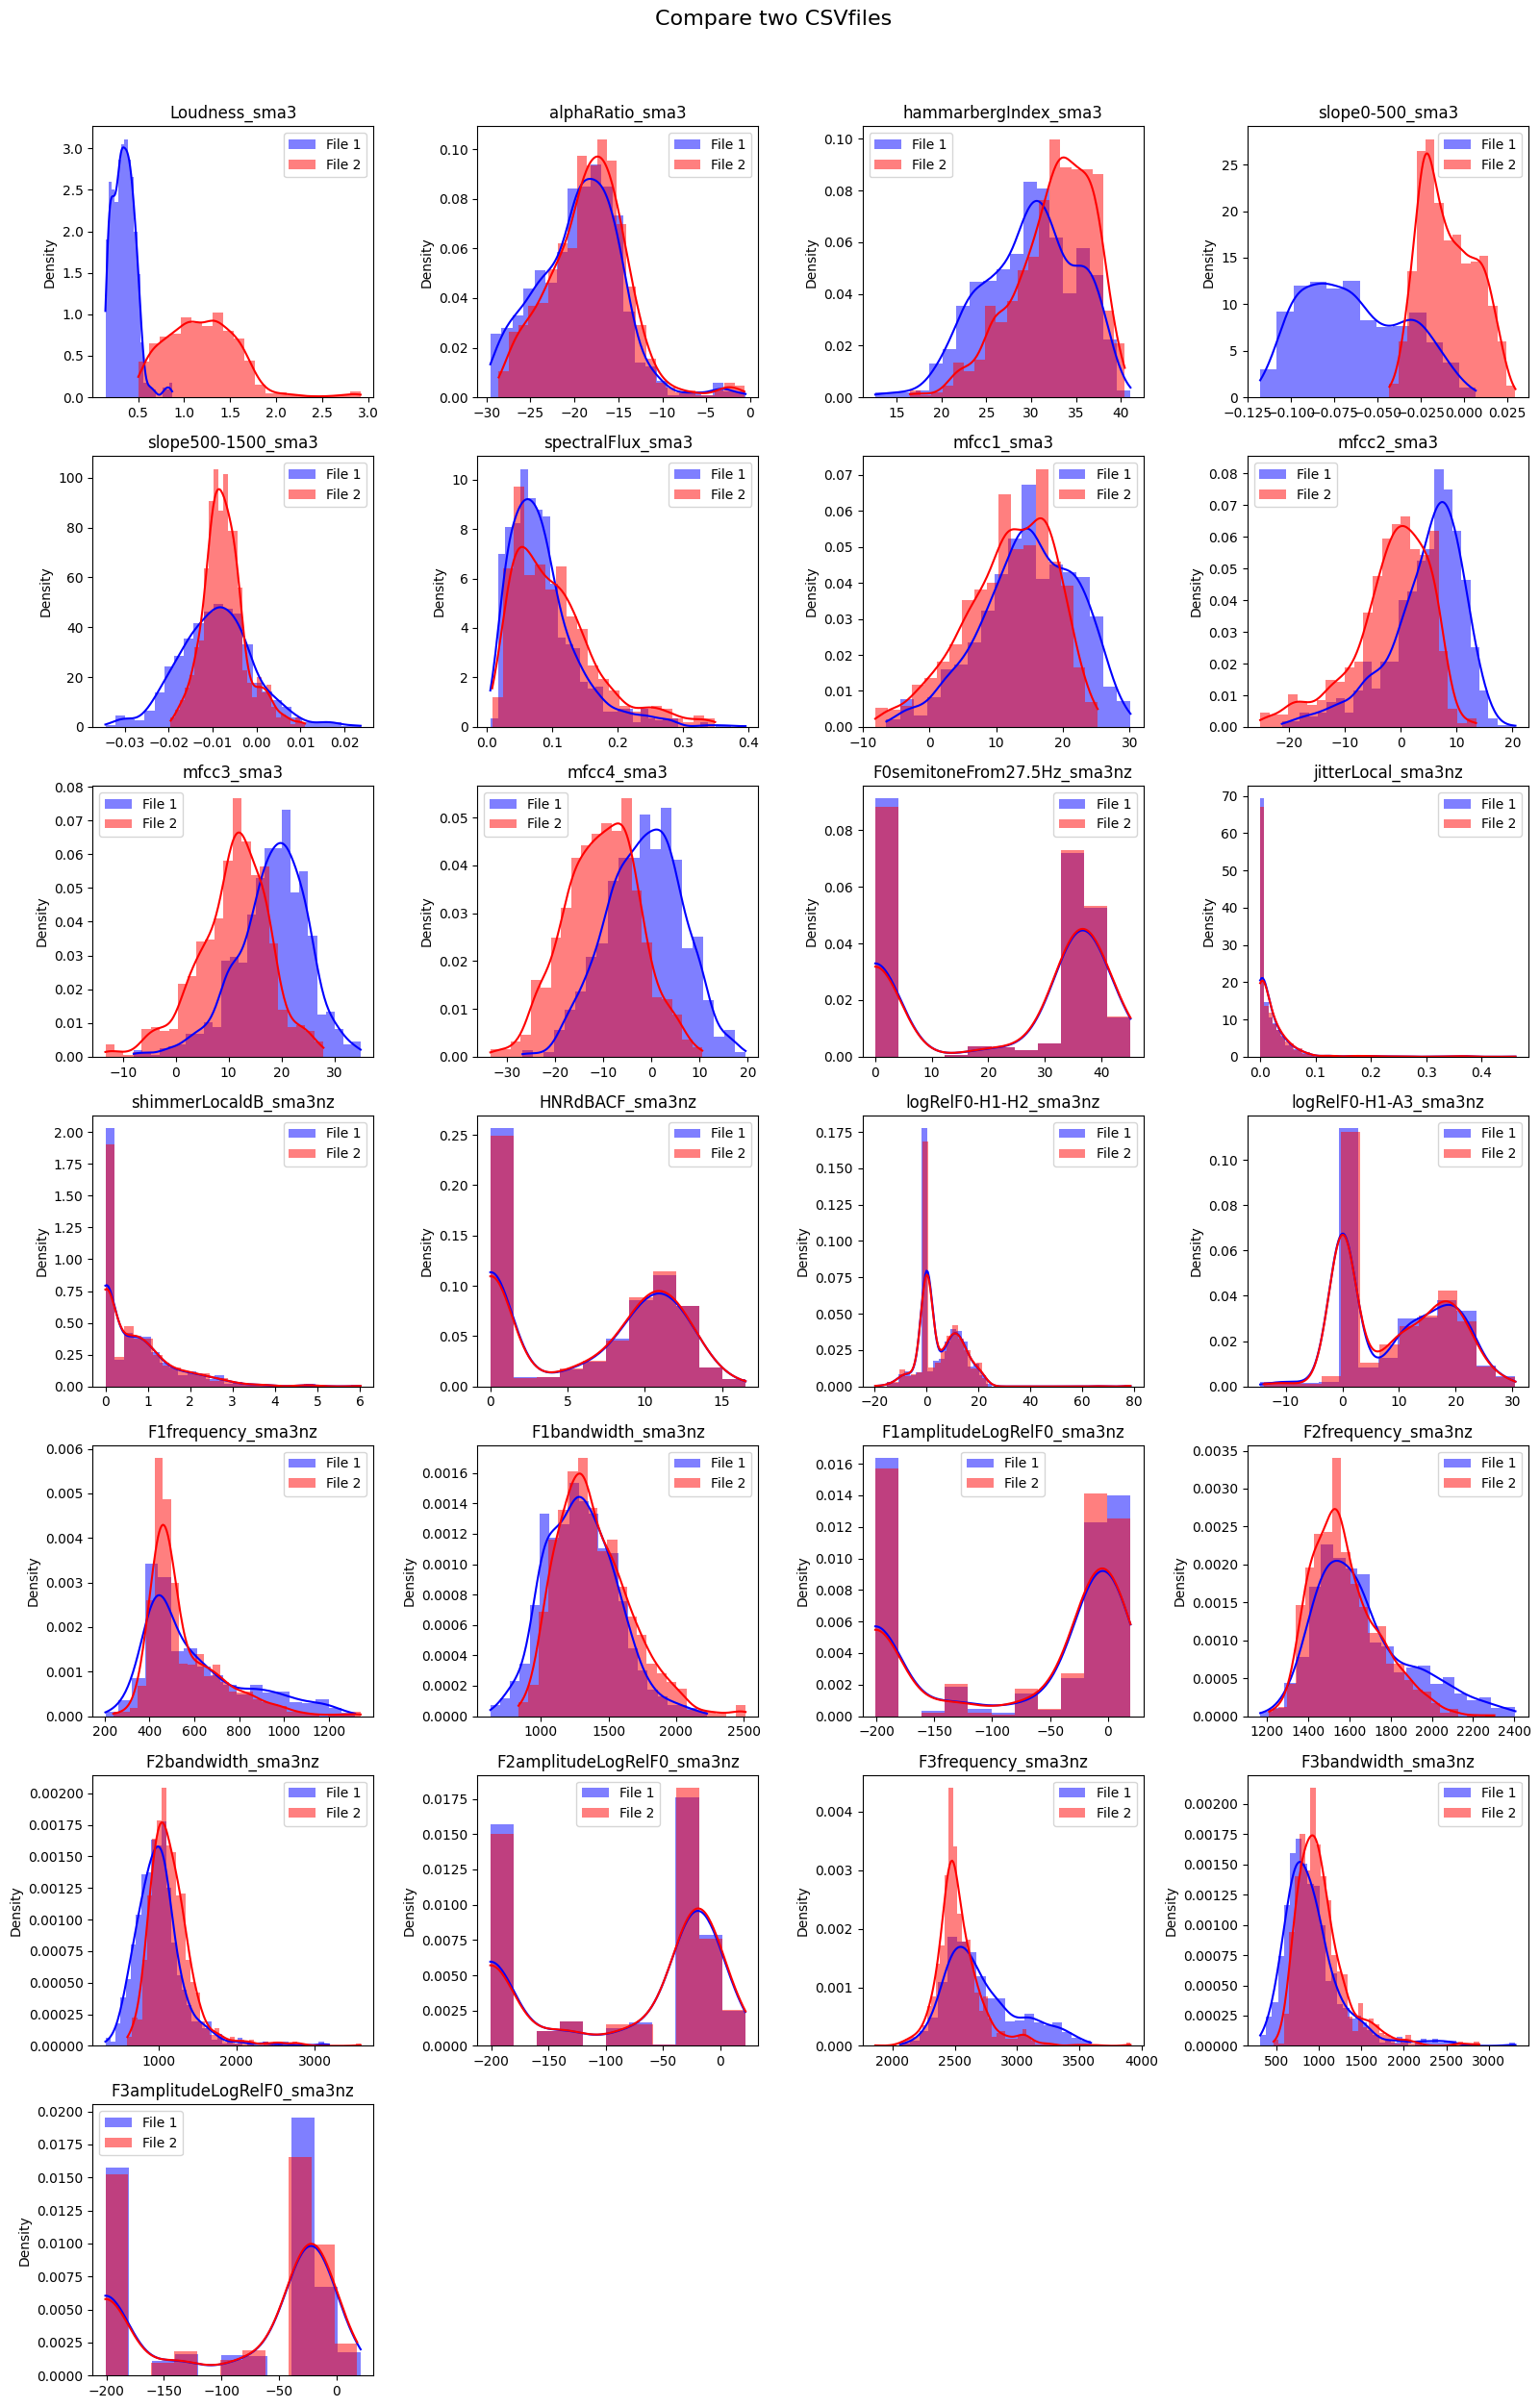

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

file1_path = './voice_csv_v2/ID32_20ms.csv'
file2_path = './voice_csv_v3/ID32_100ms.csv'

try:
    # 2つのCSVファイルを読み込む
    df1 = pd.read_csv(file1_path)
    df2 = pd.read_csv(file2_path)
except FileNotFoundError:
    print("ファイルが見つからない")

features_to_drop = ['start', 'end', 'label', 'original_start', 'original_end']

df1 = df1.drop(columns=features_to_drop)
df2 = df2.drop(columns=features_to_drop)

common_features = df1.columns.intersection(df2.columns)
n_features = len(common_features)

if n_features == 0:
    print("エラー: 2つのファイルに共通する特徴量（列）がありません。")
else:
    # プロットのグリッドサイズを計算（1行に最大4つのグラフを表示）
    n_cols = 4
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    # 1次元の場合、axesをリストに変換して扱いやすくする
    if n_rows * n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    fig.suptitle('Compare two CSVfiles', fontsize=16, y=1.02)

    # 各特徴量についてループ処理
    for i, feature in enumerate(common_features):
        ax = axes[i]
        
        # Seabornを使ってヒストグラムとKDEプロットを重ねて描画
        sns.histplot(df1[feature], color="blue", label='File 1', kde=True, stat="density", linewidth=0, ax=ax)
        sns.histplot(df2[feature], color="red", label='File 2', kde=True, stat="density", linewidth=0, ax=ax)
        
        ax.set_title(feature)
        ax.set_xlabel('') # X軸のラベルは不要なため非表示
        ax.legend()

    # 使わない余分なプロットエリアを非表示にする
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()




#2つのファイルでの分布の違い

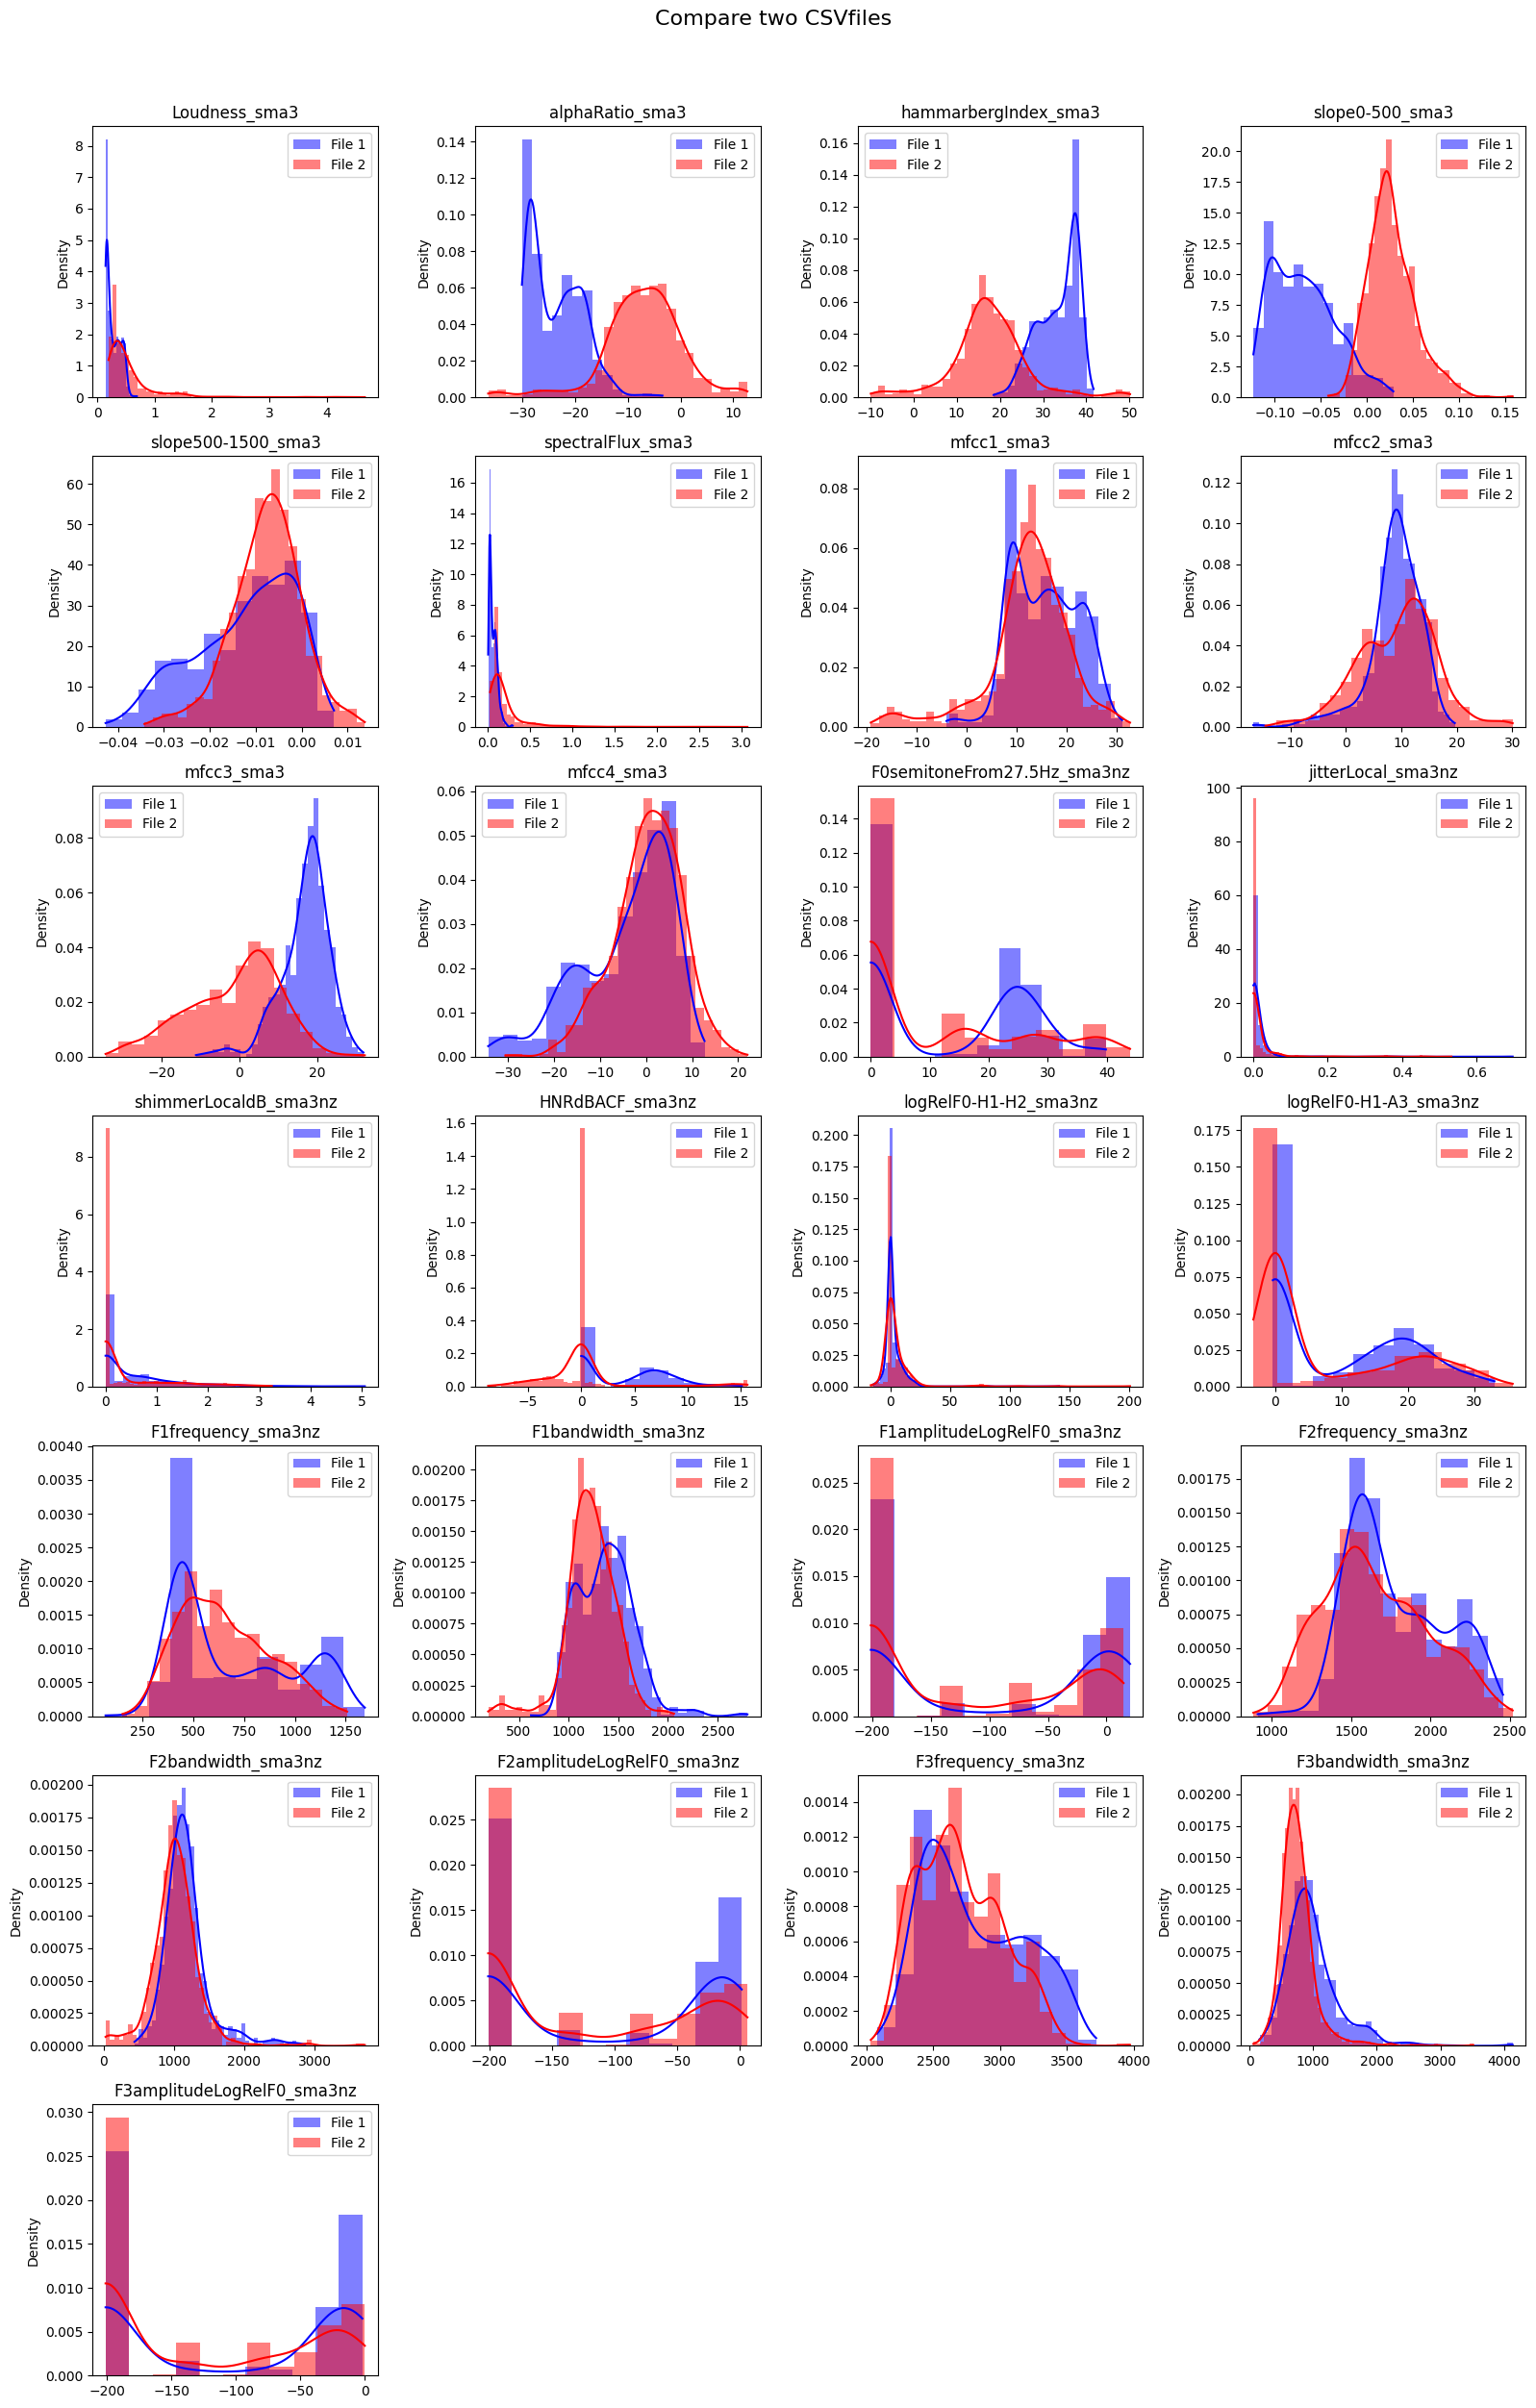

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

file1_path = './voice_csv_v2/ID34_20ms.csv'
file2_path = './voice_csv_v2/ID43_20ms.csv'

try:
    # 2つのCSVファイルを読み込む
    df1 = pd.read_csv(file1_path)
    df2 = pd.read_csv(file2_path)
except FileNotFoundError:
    print("ファイルが見つからない")

features_to_drop = ['start', 'end', 'label', 'original_start', 'original_end']

df1 = df1.drop(columns=features_to_drop)
df2 = df2.drop(columns=features_to_drop)

common_features = df1.columns.intersection(df2.columns)
n_features = len(common_features)

if n_features == 0:
    print("エラー: 2つのファイルに共通する特徴量（列）がありません。")
else:
    # プロットのグリッドサイズを計算（1行に最大4つのグラフを表示）
    n_cols = 4
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    # 1次元の場合、axesをリストに変換して扱いやすくする
    if n_rows * n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    fig.suptitle('Compare two CSVfiles', fontsize=16, y=1.02)

    # 各特徴量についてループ処理
    for i, feature in enumerate(common_features):
        ax = axes[i]
        
        # Seabornを使ってヒストグラムとKDEプロットを重ねて描画
        sns.histplot(df1[feature], color="blue", label='File 1', kde=True, stat="density", linewidth=0, ax=ax)
        sns.histplot(df2[feature], color="red", label='File 2', kde=True, stat="density", linewidth=0, ax=ax)
        
        ax.set_title(feature)
        ax.set_xlabel('') # X軸のラベルは不要なため非表示
        ax.legend()

    # 使わない余分なプロットエリアを非表示にする
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

#グリッドサーチ後

In [53]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ファイルとdeliriumの結合
folder_path = Path('./voice_csv_v2')
all_files = list(folder_path.glob('*.csv'))

df = pd.DataFrame({'filepath': all_files})

files_df = df 

files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)

files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)_')
files_df['ID'] = files_df['ID'].astype(int)
#print(files_df.head())

labels_df = pd.read_csv('./delirium.csv')
#print(labels_df)

file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')

file_with_labels_df.drop(columns=['Sex'], inplace=True)
#print(file_with_labels_df)
#print(file_with_labels_df.columns)

#Group KFold
all_dfs = []
groups = [] 
y_list = []

for i , row in file_with_labels_df.iterrows():
    file_df = pd.read_csv(row['filepath'])

    file_df = file_df.drop(columns=columns_drop, errors='ignore')

    print(file_df)

    all_dfs.append(file_df)

    groups.extend([row['ID']] * len(file_df))

    y_list.extend([row['Delirium']] * len(file_df))

    #print(len(groups))

X_all = pd.concat(all_dfs, ignore_index=True)
y_all = pd.Series(y_list)
# groupsはnumpy配列に変換しておくと確実です
groups = np.array(groups)

print(f"全データ読み込み完了。")
print(f"X_all の形状: {X_all.shape}")
print(f"y_all の形状: {y_all.shape}")
print(f"groups の形状: {groups.shape}\n")

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 4]
}

model = RandomForestClassifier(random_state=42)
gkf = GroupKFold(n_splits=65)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=gkf,  
    scoring='accuracy',
    n_jobs=-1 
)

#print(X_all)

grid_search.fit(X_all, y_all, groups=groups) 

# --- 4. 結果の表示 ---
print("\n--- グリッドサーチ完了 ---")
print(f"最も良いスコア: {grid_search.best_score_:.4f}")
print(f"最も良いパラメータ: {grid_search.best_params_}")




     Loudness_sma3  spectralFlux_sma3  F0semitoneFrom27.5Hz_sma3nz  \
0         0.144024           0.005333                          0.0   
1         0.143453           0.011333                          0.0   
2         0.144741           0.016569                          0.0   
3         0.146089           0.017209                          0.0   
4         0.141315           0.016856                          0.0   
..             ...                ...                          ...   
955       0.159785           0.018947                          0.0   
956       0.158318           0.018928                          0.0   
957       0.151304           0.017704                          0.0   
958       0.149634           0.018334                          0.0   
959       0.143161           0.019632                          0.0   

     jitterLocal_sma3nz  shimmerLocaldB_sma3nz  HNRdBACF_sma3nz  \
0                   0.0                    0.0              0.0   
1                   0.0  

KeyboardInterrupt: 